# Project  16 Time sereies analysis and powerbi Spanish electricity demand forecasting 
## Part 2 Visualization

In [ ]:
# Step 1 Import libraries 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pptx import Presentation
from pptx.dml.color import RGBColor
from pptx.enum.shapes import MSO_AUTO_SHAPE_TYPE, MSO_CONNECTOR
from pptx.enum.text import MSO_ANCHOR, PP_ALIGN
from pptx.util import Inches, Pt


In [ ]:
# Step 2/ Figure Setting 

In [2]:
# Basic figure setting
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Unified color palette
COLOR_DEMAND = "#2E86AB"      # blue for demand trend
COLOR_BAR = "#58A55C"         # green for bar charts
COLOR_SCATTER = "#8E44AD"     # purple for scatter plots
COLOR_ANOMALY = "#C0392B"     # red for anomalies
COLOR_BEFORE = "#AAB7B8"      # grey for before-cleaning data
COLOR_MODEL = "#E67E22"       # orange for model result
COLOR_ACTUAL = "#2C3E50"      # dark color for actual values
COLOR_RF = "#16A085"          # green-blue for Random Forest
COLOR_XGB = "#D35400"         # orange-red for XGBoost

In [1]:
def Read_CSV_file(file_location):
    df = pd.read_csv(file_location)
    return df
    
energy_df_location = "Datasets/energy_dataset.csv"
weather_df_location = "Datasets/weather_features.csv"
###########################################################
energy_df = Read_CSV_file(energy_df_location )
weather_df = Read_CSV_file(weather_df_location)
######################################################
def Shape_dataframe(energy_df,weather_df):
    print("Energy data shape:", energy_df.shape)
    display(energy_df.head())
    
    print("Weather data shape:", weather_df.shape)
    display(weather_df.head())

###########################################################
Shape_dataframe(energy_df,weather_df)

def show_columns(df):
    cols = df.columns.tolist()

    print("Columns:")
    print(cols)

    print("\nTotal columns:", len(cols))
######################################################################
show_columns(energy_df)
show_columns(weather_df)

NameError: name 'pd' is not defined

# Visulize 1 view the datasets shapes and structures

Energy data shape: (35064, 29)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


Weather data shape: (178396, 17)


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


# Visualize 3 check columns name as a list in both datasets

Columns:
['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind offshore eday ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']

Total columns: 29
Columns:
['dt_iso', 'city_name', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_al

# Visualize 4 Show missing values in df

In [5]:
def Show_missing_values(df):
    print("Missing values in  data:")
    display(df.isnull().sum().sort_values(ascending=False).head(50))
    
Show_missing_values(energy_df)
print("------------------------------------------------")
Show_missing_values(weather_df)

Missing values in  data:


generation hydro pumped storage aggregated     35064
forecast wind offshore eday ahead              35064
total load actual                                 36
generation hydro run-of-river and poundage        19
generation hydro pumped storage consumption       19
generation waste                                  19
generation marine                                 19
generation fossil oil                             19
generation biomass                                19
generation fossil peat                            18
generation fossil gas                             18
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation wind onshore                           18
generation geothermal                             18
generation fossil oil shale                       18
generation fossil hard coal                       18
generation solar                                  18
generation other renewable                    

------------------------------------------------
Missing values in  data:


dt_iso                 0
city_name              0
temp                   0
temp_min               0
temp_max               0
pressure               0
humidity               0
wind_speed             0
wind_deg               0
rain_1h                0
rain_3h                0
snow_3h                0
clouds_all             0
weather_id             0
weather_main           0
weather_description    0
weather_icon           0
dtype: int64

In [6]:
# Convert time columns to datetime
def convert_time_columns_datetime(energy_df, weather_df):

    energy_copy = energy_df.copy()
    weather_copy = weather_df.copy()

    energy_copy["time"] = pd.to_datetime(
        energy_copy["time"], utc=True
    )

    weather_copy["dt_iso"] = pd.to_datetime(
        weather_copy["dt_iso"], utc=True
    )
    return energy_copy, weather_copy


# Remove timezone information
def remove_timezone(energy_df, weather_df):
    energy_copy = energy_df.copy()
    weather_copy = weather_df.copy()

    energy_copy["time"] = energy_copy["time"].dt.tz_convert(None)
    weather_copy["dt_iso"] = weather_copy["dt_iso"].dt.tz_convert(None)

    return energy_copy, weather_copy


def rename_and_remove_duplicates(energy_df, weather_df):  
    energy = energy_df.copy()
    weather = weather_df.copy()

    # Rename weather timestamp column
    weather = weather.rename(columns={"dt_iso": "time"})

    # Remove duplicate rows
    energy = energy.drop_duplicates()
    weather = weather.drop_duplicates()

    return energy, weather

# Drop columns that are completely empty
def remove_empty_columns(energy_df, weather_df):

    energy = energy_df.copy()
    weather = weather_df.copy()

    energy = energy.dropna(axis=1, how="all")
    weather = weather.dropna(axis=1, how="all")

    return energy, weather
#####################################################################################
def preprocess_data_verbose(energy_df, weather_df):

    print("=" * 60)
    print("STEP 1: Convert time columns to datetime")
    print("=" * 60)

    energy, weather = convert_time_columns_datetime(
        energy_df, weather_df
    )

    print("Energy time sample:")
    print(energy["time"].head())

    print("\nWeather dt_iso sample:")
    print(weather["dt_iso"].head())

    print("\n" + "=" * 60)
    print("STEP 2: Remove timezone")
    print("=" * 60)

    energy, weather = remove_timezone(
        energy, weather
    )

    print("Energy time sample:")
    print(energy["time"].head())

    print("\nWeather dt_iso sample:")
    print(weather["dt_iso"].head())

    print("\n" + "=" * 60)
    print("STEP 3: Remove completely empty columns")
    print("=" * 60)

    old_energy_shape = energy.shape
    old_weather_shape = weather.shape

    energy, weather = remove_empty_columns(
        energy, weather
    )

    print(f"Energy: {old_energy_shape} -> {energy.shape}")
    print(f"Weather: {old_weather_shape} -> {weather.shape}")

    print("\n" + "=" * 60)
    print("STEP 4: Rename time column & remove duplicates")
    print("=" * 60)

    old_energy_rows = len(energy)
    old_weather_rows = len(weather)

    energy, weather = rename_and_remove_duplicates(
        energy, weather
    )

    print(
        f"Energy duplicates removed: "
        f"{old_energy_rows - len(energy)}"
    )

    print(
        f"Weather duplicates removed: "
        f"{old_weather_rows - len(weather)}"
    )

    print("\nFinal Energy Shape:", energy.shape)
    print("Final Weather Shape:", weather.shape)

    print("\nEnergy Columns:")
    print(energy.columns.tolist())

    print("\nWeather Columns:")
    print(weather.columns.tolist())

    print("\nEnergy Sample:")
    print(energy.head())

    print("\nWeather Sample:")
    print(weather.head())

    return energy, weather


# Usage
energy_clean, weather_clean = preprocess_data_verbose(
    energy_df, weather_df )

STEP 1: Convert time columns to datetime
Energy time sample:
0   2014-12-31 23:00:00+00:00
1   2015-01-01 00:00:00+00:00
2   2015-01-01 01:00:00+00:00
3   2015-01-01 02:00:00+00:00
4   2015-01-01 03:00:00+00:00
Name: time, dtype: datetime64[us, UTC]

Weather dt_iso sample:
0   2014-12-31 23:00:00+00:00
1   2015-01-01 00:00:00+00:00
2   2015-01-01 01:00:00+00:00
3   2015-01-01 02:00:00+00:00
4   2015-01-01 03:00:00+00:00
Name: dt_iso, dtype: datetime64[us, UTC]

STEP 2: Remove timezone
Energy time sample:
0   2014-12-31 23:00:00
1   2015-01-01 00:00:00
2   2015-01-01 01:00:00
3   2015-01-01 02:00:00
4   2015-01-01 03:00:00
Name: time, dtype: datetime64[us]

Weather dt_iso sample:
0   2014-12-31 23:00:00
1   2015-01-01 00:00:00
2   2015-01-01 01:00:00
3   2015-01-01 02:00:00
4   2015-01-01 03:00:00
Name: dt_iso, dtype: datetime64[us]

STEP 3: Remove completely empty columns
Energy: (35064, 29) -> (35064, 27)
Weather: (178396, 17) -> (178396, 17)

STEP 4: Rename time column & remove dupli

In [8]:
def aggregate_weather_data(weather_df):
    """
    Aggregate weather data by time using the mean
    of all numerical columns.
    """

    weather = weather_df.copy()

    weather_numeric_cols = weather.select_dtypes(
        include=[np.number]   ).columns.tolist()

    weather_avg = (
        weather.groupby("time")[weather_numeric_cols]
        .mean()
        .reset_index())

    return weather_avg

In [9]:
import numpy as np
def combine_weather_energy_using_time(df_energy, df_weather):
    """
    Merge energy and weather data on time
    using copies of the input DataFrames.
    """

    energy = df_energy.copy()
    weather = df_weather.copy()

    df_combine = pd.merge(
        energy,
        weather,
        on="time",
        how="inner"
    )

    return df_combine
    
weather_avg = aggregate_weather_data(weather_clean)
combined_df = combine_weather_energy_using_time(   energy_clean,  weather_avg)

print(combined_df.shape)
display(combined_df.head())

(35064, 39)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id
0,2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,0.0,0.0,800.0
1,2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,0.0,0.0,800.0
2,2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,0.0,0.0,800.0
3,2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,0.0,0.0,800.0
4,2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,0.0,0.0,800.0


In [27]:
# STEP 1: Handle abnormal pressure values

def clean_pressure_anomalies(df):  
    df_copy = df.copy()
    if "pressure" in df_copy.columns:
        pressure_anomaly = ( (df_copy["pressure"] < 900) | (df_copy["pressure"] > 1100) )
        df_copy.loc[pressure_anomaly,"pressure"] = np.nan
    return df_copy
    
# STEP 2: Interpolate missing values
def interpolate_missing_values(df): 
    df_copy = df.copy()
    df_copy = df_copy.set_index("time")
    numeric_cols = df_copy.select_dtypes(include=[np.number]).columns

    df_copy[numeric_cols] = (df_copy[numeric_cols].interpolate(method="time").ffill().bfill())
    df_copy = df_copy.reset_index()
    return df_copy
# STEP 3: Pressure summary
def get_pressure_summary(df):   
    df_copy = df.copy()
    if "pressure" not in df_copy.columns:
        return None
    return {
        "pressure_min": df_copy["pressure"].min(),
        "pressure_max": df_copy["pressure"].max(),
        "missing_pressure": df_copy["pressure"].isnull().sum()
    }
def clean_weather_dataset(df): 
    df_clean = clean_pressure_anomalies(df)
    df_clean = interpolate_missing_values(df_clean)
    return df_clean    
def convert_temperature(df):
    if "temp" in df.columns:
        if df["temp"].mean() > 100:
            df["temp_c"] = df["temp"] - 273.15
        else:
            df["temp_c"] = df["temp"]
    
    return(df[["time", "total load actual", "temp_c"]])
############################################################################
clean_combine_df = clean_weather_dataset(combined_df)
    
df_copy = clean_combine_df.copy()
clean_combine_df = convert_temperature(df_copy)

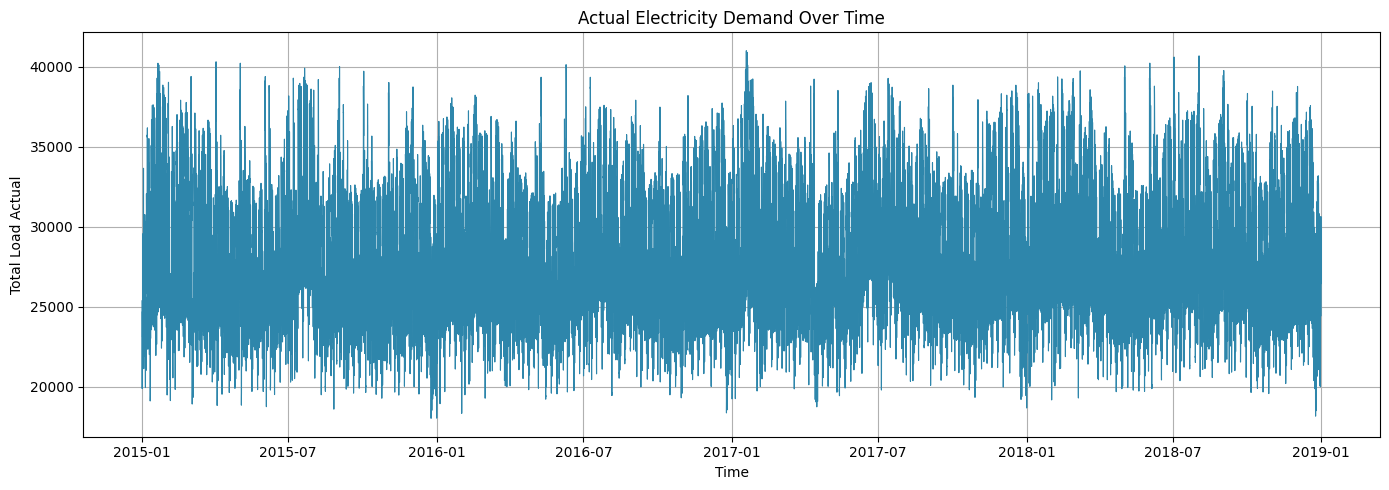

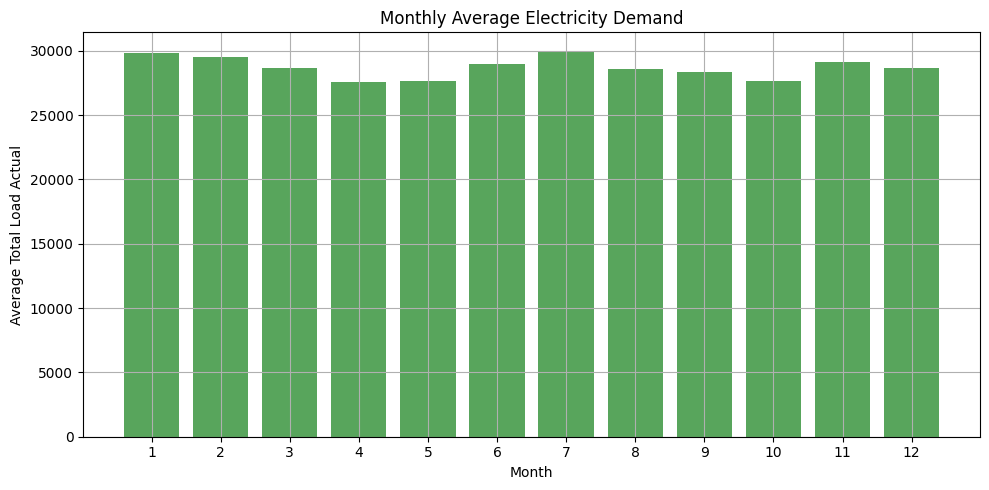

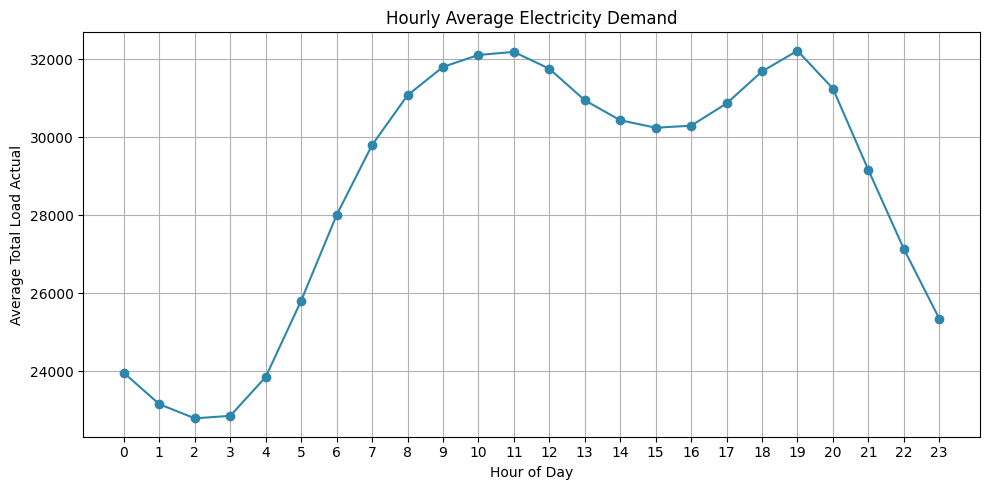

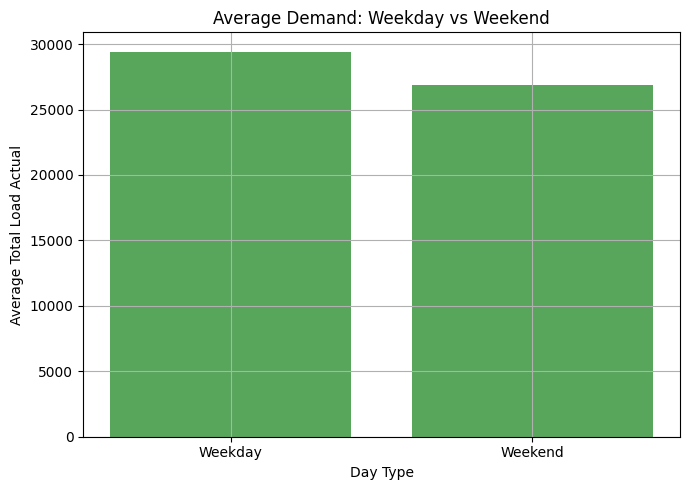

In [30]:
def Visulize_total_load(df):
    
    plt.figure(figsize=(14, 5))
    plt.plot(df["time"],df["total load actual"], linewidth=0.8, color=COLOR_DEMAND)
    
    plt.title("Actual Electricity Demand Over Time")
    plt.xlabel("Time")
    plt.ylabel("Total Load Actual")
    plt.tight_layout()
    plt.show()
#####################################################################
def Visualize_data_points(df):
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month
    df["hour"] = df["time"].dt.hour
    df["dayofweek"] = df["time"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    monthly_demand = df.groupby("month")["total load actual"].mean()
    
    plt.figure(figsize=(10, 5))
    plt.bar(monthly_demand.index, monthly_demand.values, color=COLOR_BAR)
    
    plt.title("Monthly Average Electricity Demand")
    plt.xlabel("Month")
    plt.ylabel("Average Total Load Actual")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.show()

#############################################################
def Visualize_hourly_demand(df):
    hourly_demand = df.groupby("hour")["total load actual"].mean()
    
    plt.figure(figsize=(10, 5))
    plt.plot(hourly_demand.index, hourly_demand.values, marker="o", color=COLOR_DEMAND)
    
    plt.title("Hourly Average Electricity Demand")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average Total Load Actual")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.show()
def Visualize_weekly_demand(df):
    
    weekend_demand = df.groupby("is_weekend")["total load actual"].mean()
    
    plt.figure(figsize=(7, 5))
    plt.bar(["Weekday", "Weekend"], weekend_demand.values, color=COLOR_BAR)
    
    plt.title("Average Demand: Weekday vs Weekend")
    plt.xlabel("Day Type")
    plt.ylabel("Average Total Load Actual")
    plt.tight_layout()
    plt.show()
########################################################################
df = clean_combine_df.copy()
Visulize_total_load( df)
Visualize_data_points(df)
Visualize_hourly_demand(df)
Visualize_weekly_demand(df)

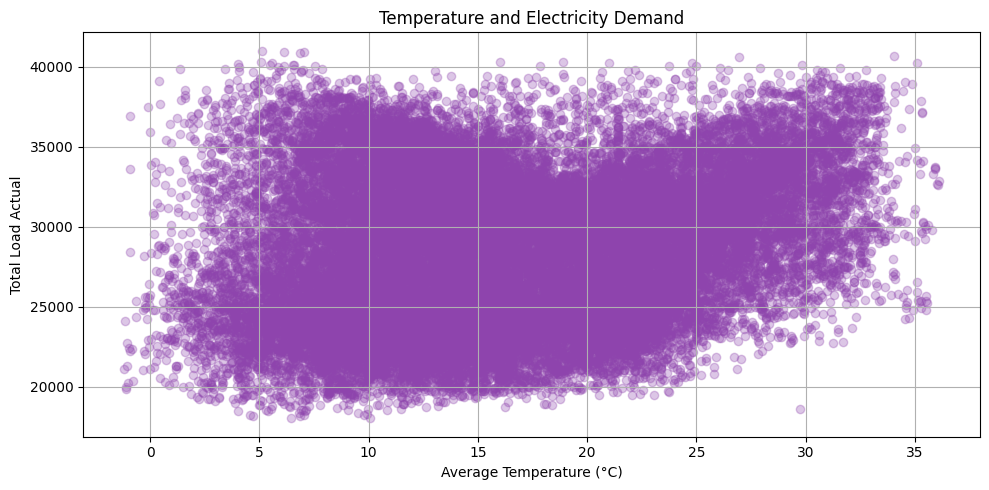

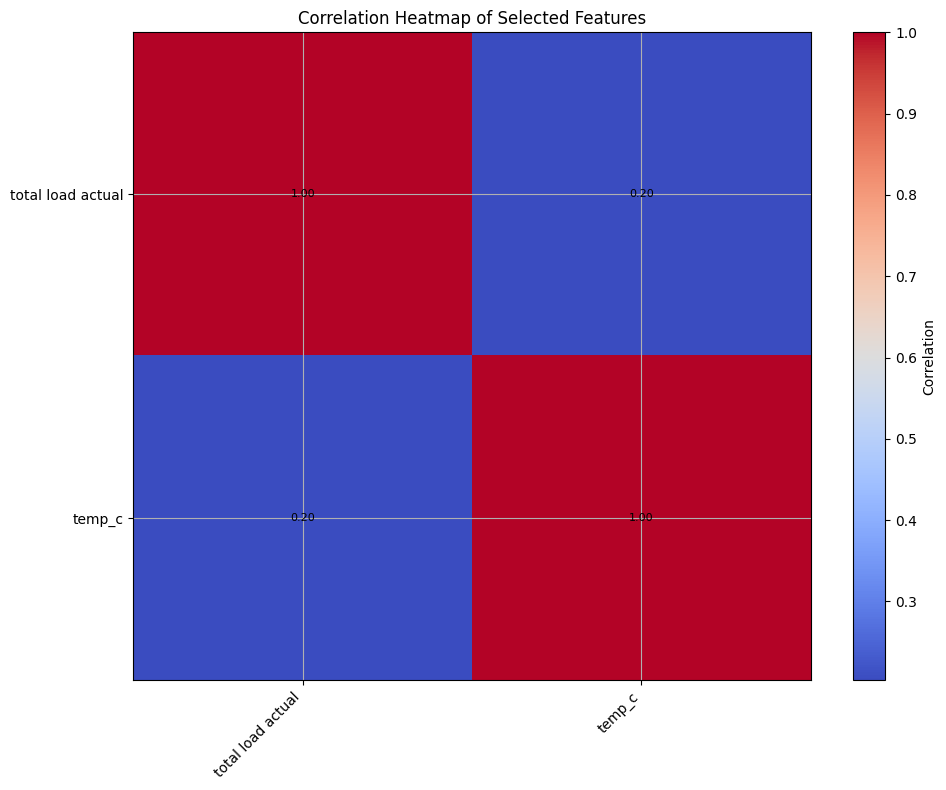

In [29]:
def Visualize_features_correlations(df):
    selected_corr_cols = [
        "total load actual",
        "total load forecast",
        "price day ahead",
        "temp_c",
        "humidity",
        "pressure",
        "wind_speed",
        "clouds_all",
        "forecast solar day ahead",
        "forecast wind onshore day ahead"
    ]
    
    selected_corr_cols = [col for col in selected_corr_cols if col in df.columns]
    
    corr_matrix = df[selected_corr_cols].corr()
    
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
    plt.colorbar(label="Correlation")
    
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    
    plt.title("Correlation Heatmap of Selected Features")
    plt.tight_layout()
    plt.show()

#########################################################################
def Visualize_temperature_electricity_demand(df):
    plt.figure(figsize=(10, 5))
    plt.scatter(df["temp_c"], df["total load actual"], alpha=0.3, color=COLOR_SCATTER)
    
    plt.title("Temperature and Electricity Demand")
    plt.xlabel("Average Temperature (°C)")
    plt.ylabel("Total Load Actual")
    plt.tight_layout()
    plt.show()

    
df2 = clean_combine_df.copy()
Visualize_temperature_electricity_demand(df2)
df2 = clean_combine_df.copy()
Visualize_features_correlations(df2)
